<a href="https://colab.research.google.com/github/william-idam-inya/Group-26_Student-Academic-Outcome-Prediction_Notebook.ipynb/blob/main/Group_26_Student_Academic_Outcome_Prediction_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STUDENT ACADEMIC OUTCOME PREDICTION NOTEBOOK

*Disclaimer: All codes are assisted by Chatgpt and Adapted for this dataset except otherwise stated.*

## 1. Installing and Importing of Libraries.

We are importing **Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Imbalanced-learn, XGBoost, and Warnings.**

We are installing and importing these libraries to provide the essential tools needed for our project. **Pandas and NumPy** are used for data handling and numerical operations, **Matplotlib and Seaborn** for data visualization, **Scikit-learn** for data preprocessing, machine learning, and model evaluation, Imbalanced-learn for handling class imbalance, **XGBoost** for an additional machine-learning model, and **Warnings** for managing unnecessary warning messages in the notebook.


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
import sklearn
import imblearn
import xgboost

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Dataset Loading

**We are importing the dataset as python code**

*This Dataset we are using is from UCI Machine Learning Repository (archive.ics.uci.edu).*

**Size:** *4,424 rows × 36 input features + 1 target*

**Target classes:** *Dropout (1,421); Enrolled (794); Graduate (2,209)*

**Features include:** *demographics (age, gender, marital status, nationality), socio-economic (parents'
qualification/occupation, scholarship, debtor, tuition status), academic path (application mode, course, previous
qualification, curricular units 1st & 2nd semester grades/approvals), and macroeconomic context (unemployment
rate, inflation, GDP at enrollment).*

*Citation (APA): Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). Predict students' dropout and
academic success [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89*

### 2.1 Installing of the ucimlrepo package

In [ ]:
!pip install ucimlrepo

### 2.2.Importing of the dataset into our code

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# metadata
print(predict_students_dropout_and_academic_success.metadata)

# variable information
print(predict_students_dropout_and_academic_success.variables)

{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

In [ ]:
df = pd.concat([X, y], axis=1)

## 3. Inspecting Dataset

### 3.1. Checking the Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

### 3.2. Viewing the first 5 rows

In [ ]:
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


### 3.3. Checking Target Features' value count

In [ ]:
df['Target'].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


### 3.4. Checking for Duplicates

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### 3.5 Checking for missing values

In [ ]:
df.isnull().sum()

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### 3.6. Viewing Dataset Statistical information

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


## 4. Cleaning of Dataset

### 4.1. Cleaning column names

Correcting the spelling of "natiocionality" to "nationality".

In [ ]:
df.rename(columns={"Nacionality": "Nationality"}, inplace=True)
print(df.columns.tolist())

['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nationality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


### 4.2. Checking for statistical outliers using IQR method and Handling them

#### 4.2.1 Selecting variables where an outlier analysis makes sense

We will be running **IQR** on only columns(features) **containing continous and count variables** suitable for outlier investigation.

This because, several of the interger columns are actually coded categorical variables such as *Course, Nationality, and Application mode*.

UCI identifies this dataset as containing real, categorical, and interger features.

In [ ]:
# Continuous and count variables suitable for outlier investigation

numeric_analysis_cols = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

#### 4.2.2.Running the IQR test

In [ ]:
# Detect potential outliers using the IQR method

outlier_results = []

for col in numeric_analysis_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_results.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Potential Outliers": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

,Feature,Lower Bound,Upper Bound,Number of Potential Outliers
0,Previous qualification (grade),102.500,162.500000,179
1,Admission grade,92.550,160.150000,86
2,Age at enrollment,10.000,34.000000,441
3,Curricular units 1st sem (credited),0.000,0.000000,577
4,Curricular units 1st sem (enrolled),2.000,10.000000,424
5,Curricular units 1st sem (evaluations),0.000,16.000000,158
6,Curricular units 1st sem (approved),-1.500,10.500000,180
7,Curricular units 1st sem (grade),7.400,17.000000,726
8,Curricular units 1st sem (without evaluations),0.000,0.000000,294
9,Curricular units 2nd sem (credited),0.000,0.000000,530


#### 4.2.3. Visualizing them with boxplot

This will be useful for our EDA

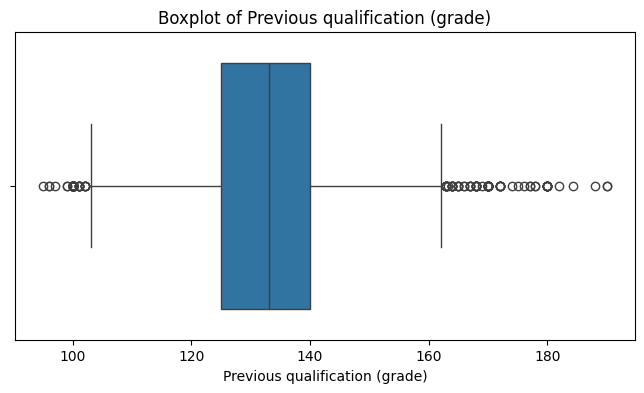

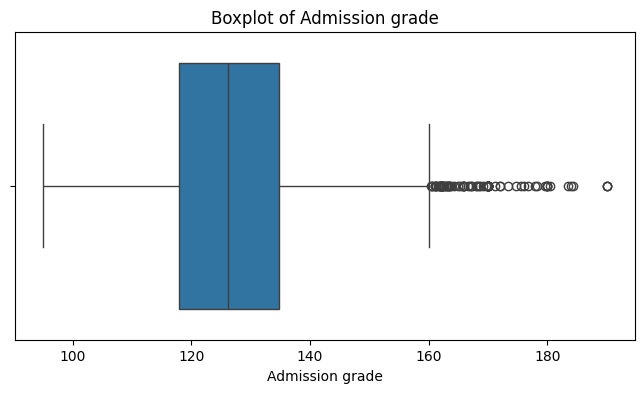

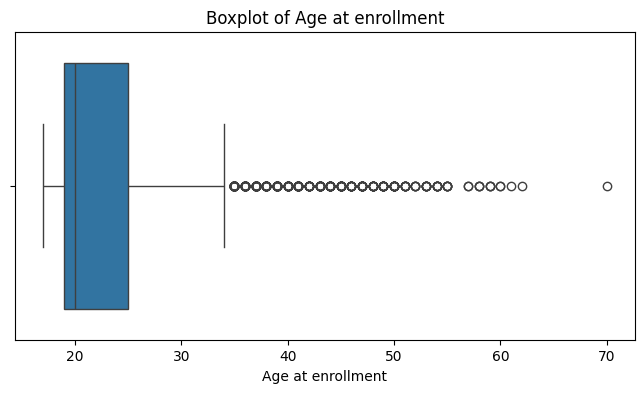

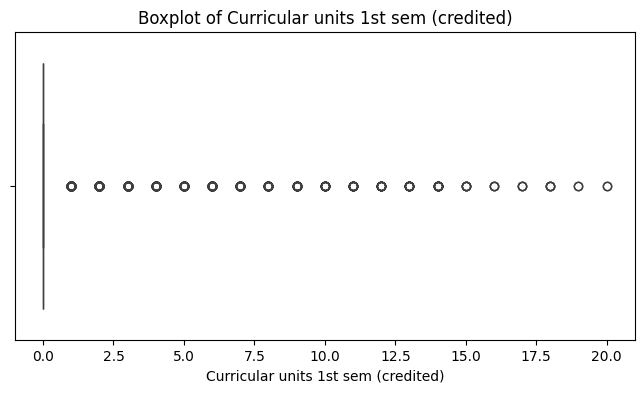

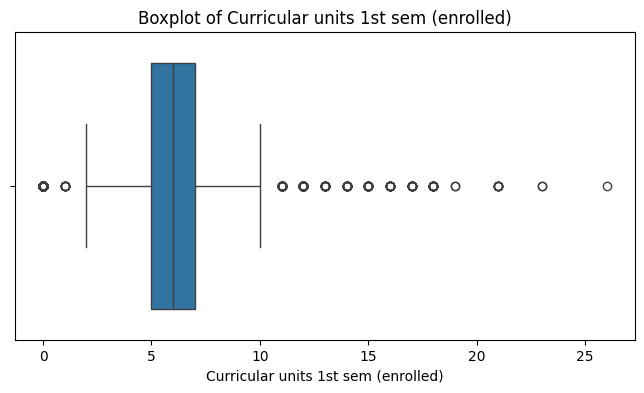

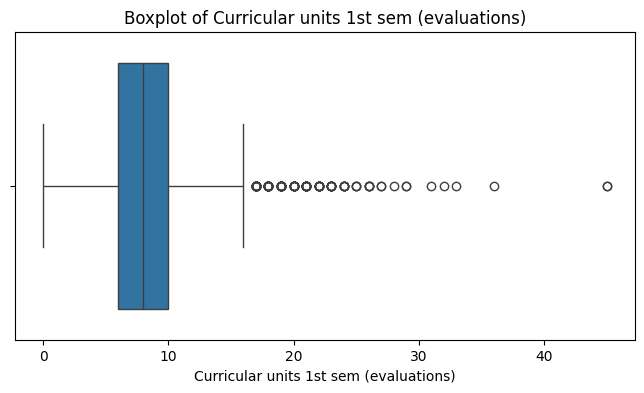

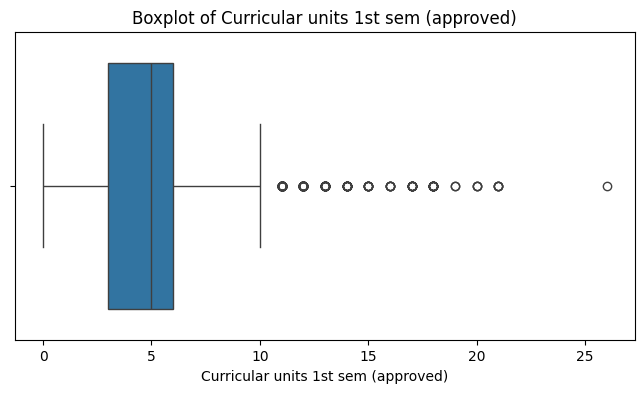

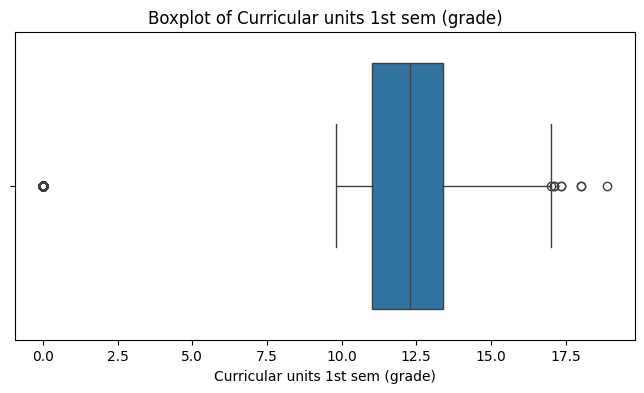

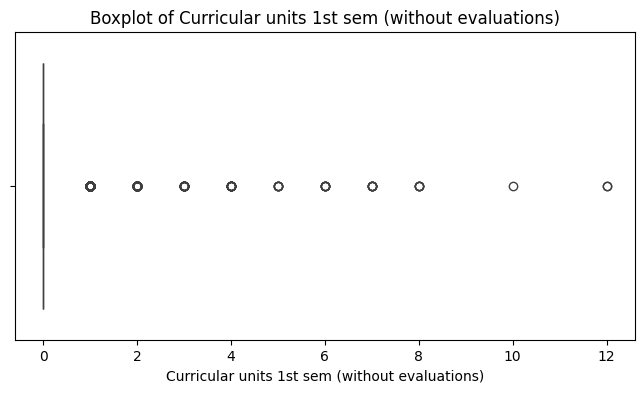

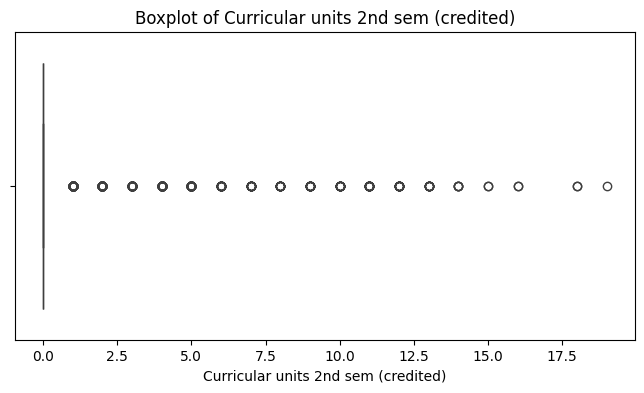

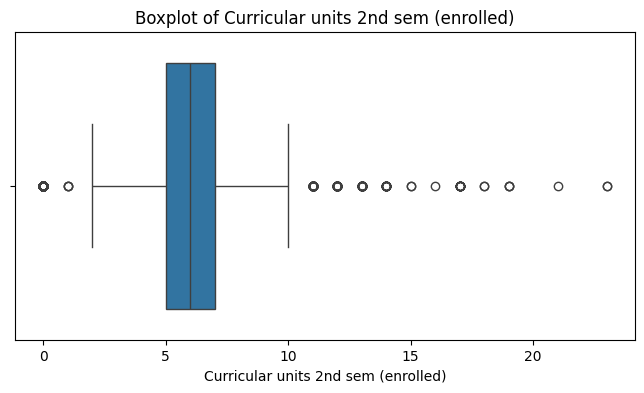

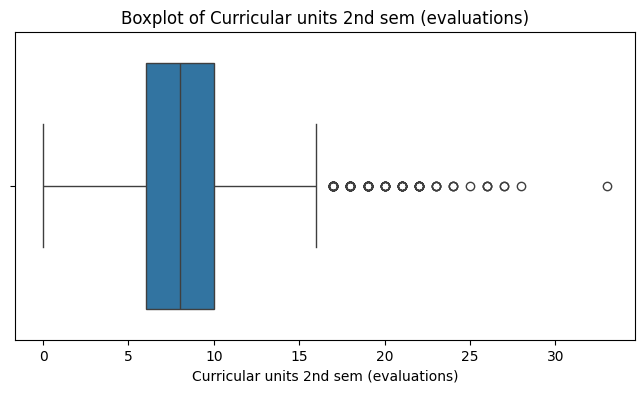

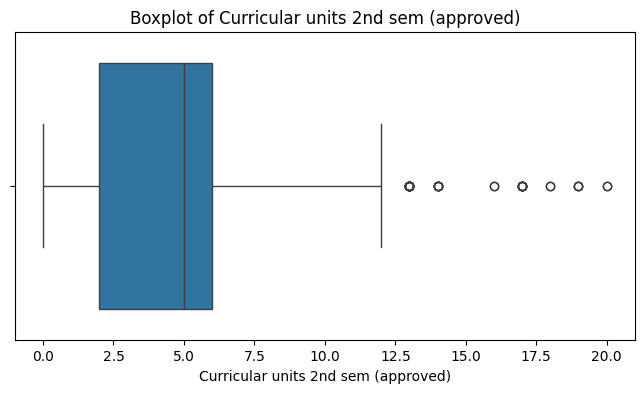

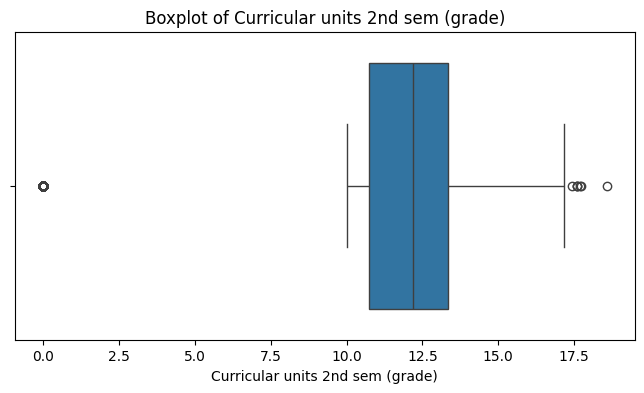

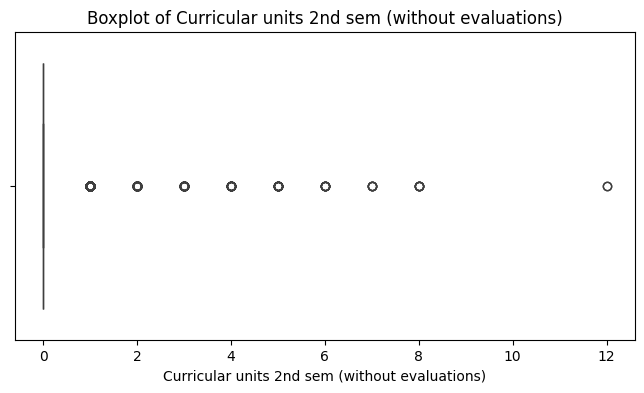

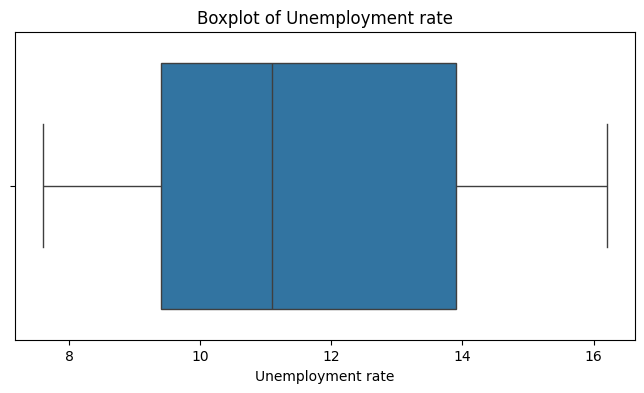

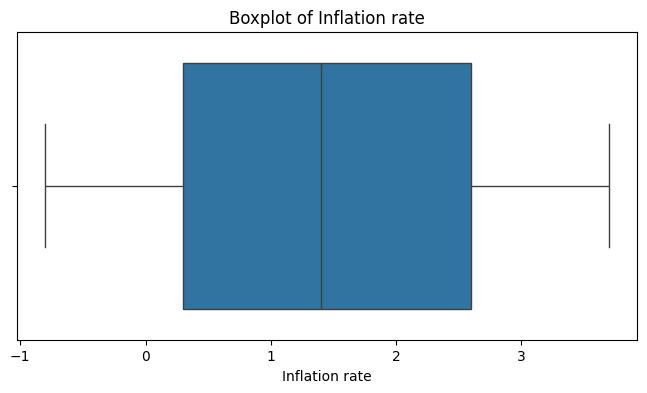

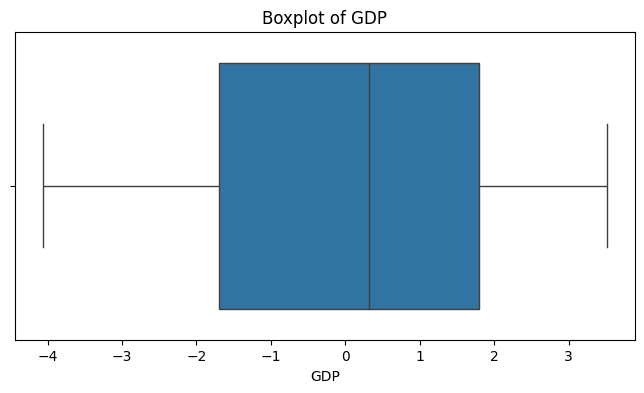

In [ ]:
# Boxplots for numerical variables

for col in numeric_analysis_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

#### 4.2.4 Handling Outliers

**Outlier Handling:** We identified Potential outliers using the Interquartile Range (IQR) method. The detected observations were reviewed based on the nature and valid ranges of the corresponding variables. Since the identified extreme values were not sufficient evidence of data-entry errors and may represent legitimate variation among students, the observations were retained. No rows were removed and no capping or clipping was applied, in order to avoid distorting potentially meaningful information in the dataset.

**Fate of Outliers:** We are therefore **keeping the Ouliers** because they are only ***stastistical outliers*** and ***not data errors***.

## 5.  Exploratory Data Analysis (EDA)

### 5.1. Target Distribution Plot

#### 5.1.1. Target Distribution with counts

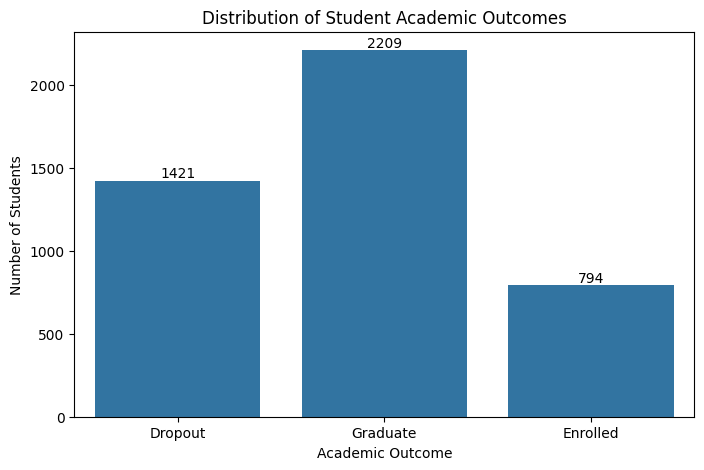

In [ ]:
# Target distribution with counts

plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x="Target")

plt.title("Distribution of Student Academic Outcomes")
plt.xlabel("Academic Outcome")
plt.ylabel("Number of Students")

# Add count labels to each bar
for container in ax.containers:
    ax.bar_label(container)

plt.show()

#### 5.1.2. Target distribution in percentage

In [ ]:
# Target distribution in percentages

target_percent = df["Target"].value_counts(normalize=True) * 100

print(target_percent)

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


#### 5.1.3. Displaying both Count and Percentage

In [ ]:
# Count and percentage of each target class

target_counts = df["Target"].value_counts()
target_percent = df["Target"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

display(target_summary)

,Count,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


The target distribution shows that the three student outcome classes are not equally represented.

Graduate students form the largest class(49.93%), followed by Dropout(32.12%), while Enrolled students are the smallest class(17.97%).

This indicates class imbalance, which we will be considering during the preprocessing and training of our model, particularly when selecting appropriate evaluation metrics and possible class-balancing techniques.

### 5.2. Numerical Feature Distribution

#### 5.2.1. Age Distribution Plot

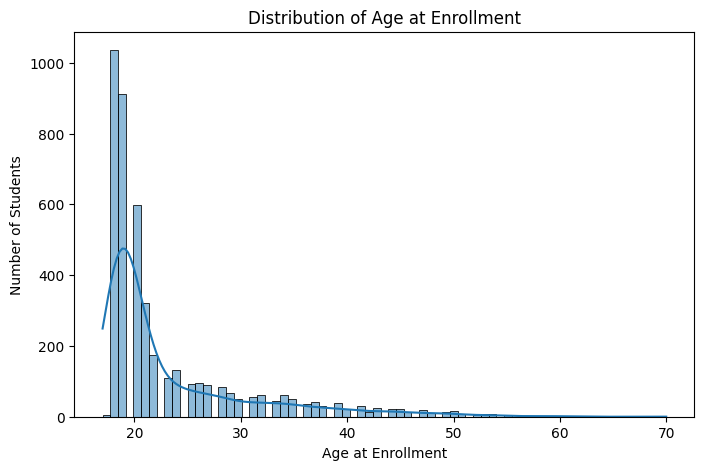

In [ ]:
# Distribution of Age at Enrollment

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age at enrollment",
    kde=True
)

plt.title("Distribution of Age at Enrollment")
plt.xlabel("Age at Enrollment")
plt.ylabel("Number of Students")

plt.show()

This Age Distribution Plot shows that "age at enrollment" is concentrated among younger students, particularly around ages 18–20, and is positively skewed(assymetrical) with a smaller number of older students.

The presence of older students contributes to the long right tail and indicating that age is not normally distributed.

Although some high ages are statistical outliers, they may represent genuine student observations and we therefore retained them rather than capping or removing them.

#### 5.2.2. Admission Grade DIstribution Plot

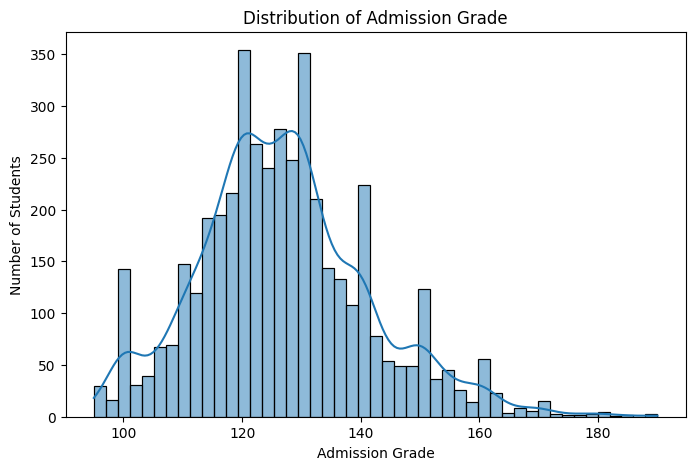

In [ ]:
# Distribution of Admission Grade

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Admission grade",
    kde=True
)

plt.title("Distribution of Admission Grade")
plt.xlabel("Admission Grade")
plt.ylabel("Number of Students")

plt.show()

The distribution of admission grades is concentrated around the middle range, particularly between approximately 115 and 140, with the highest frequencies occurring around 120–130.

The distribution is moderately positively skewed, with a smaller number of students having substantially higher admission grades, extending up to 190.

Although these higher values may appear as statistical outliers, they fall within the recorded range of the feature and may represent genuine admission results; therefore, they were retained rather than been capped or removed.

#### 5.2.1. Curricular unit 1st Semester (Grades) Distribution Plots

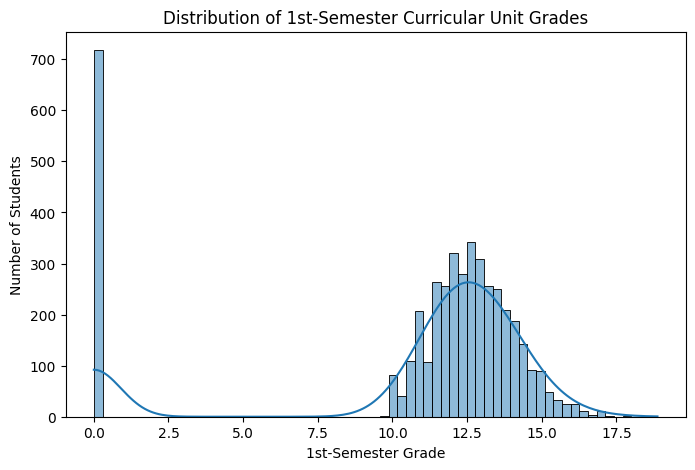

In [ ]:
# Distribution of 1st-Semester Curricular Unit Grade

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Curricular units 1st sem (grade)",
    kde=True
)

plt.title("Distribution of 1st-Semester Curricular Unit Grades")
plt.xlabel("1st-Semester Grade")
plt.ylabel("Number of Students")

plt.show()

The distribution of 1st-semester grades is concentrated mainly between approximately 10 and 14, with the highest concentration around 11–13.

The distribution is negatively assymetrical because a substantial number of students have a recorded grade of 0, producing a pronounced left lower tail.

These zero values may reflect students who did not receive an evaluated grade rather than incorrect observations, so they was not automatically treated as outliers or removed.

The small number of very high grades, including values approaching 19, fall within the expected grading range and will therefore be retained rather than been capped or clipped.

#### 5.2.4. Curricular unit 2nd Semester (Grades) Distribution Plots

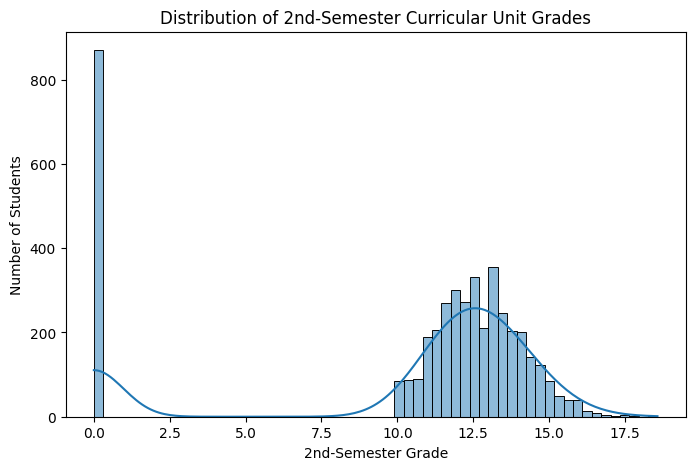

In [ ]:
# Distribution of 2nd-Semester Curricular Unit Grade

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Curricular units 2nd sem (grade)",
    kde=True
)

plt.title("Distribution of 2nd-Semester Curricular Unit Grades")
plt.xlabel("2nd-Semester Grade")
plt.ylabel("Number of Students")

plt.show()

The distribution of 2nd-semester grades is concentrated mainly between approximately 10 and 14, with the highest concentration around 12–13.

The distribution is negatively skewed because a considerable number of students have a recorded grade of 0, creating a pronounced lower tail.

These zero values may represent students who did not obtain an evaluated grade rather than incorrect observations, so they was not automatically be treated as errors or removed.

The higher grades extend to approximately 18.6 and remain within the expected grading range; therefore, these observations were retained rather than been capped or clipped.

#### 5.2.5. Curricular unit 1st Semester (enrolled) Distribution Plots

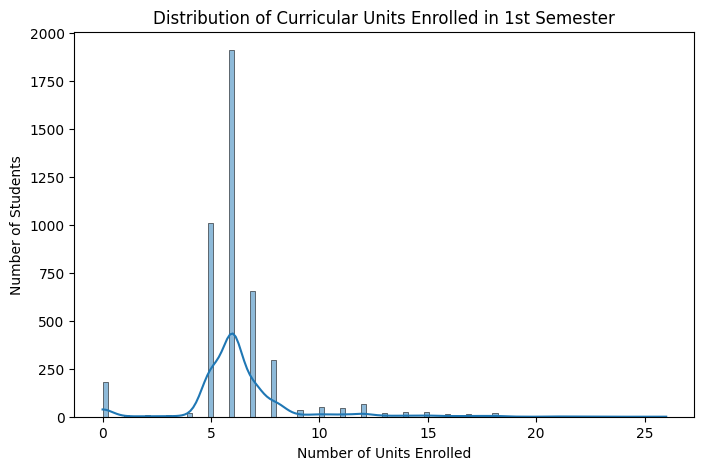

In [ ]:
# Distribution of Curricular Units Enrolled in 1st Semester

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Curricular units 1st sem (enrolled)",
    kde=True
)

plt.title("Distribution of Curricular Units Enrolled in 1st Semester")
plt.xlabel("Number of Units Enrolled")
plt.ylabel("Number of Students")

plt.show()

The distribution of curricular units enrolled in the 1st semester is concentrated mainly between 5 and 8 units, with 6 units being the most common value.

The distribution is positively skewed, with a smaller number of students enrolling in substantially more units and the values extending up to 26.

A small number of students also have 0 enrolled units, which should be retained while their meaning is considered during the data analysis rather than been automatically treated as erroneous.

The long right tail indicates that the feature is not normally distributed and will therefore be handled according to its distribution during preprocessing.

#### 5.2.6. Curricular unit 2nd Semester (enrolled) Distribution Plots

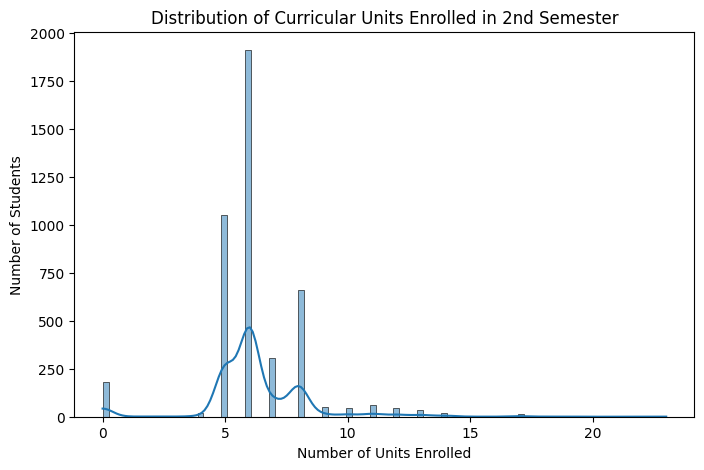

In [ ]:
# Distribution of Curricular Units Enrolled in 2nd Semester

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Curricular units 2nd sem (enrolled)",
    kde=True
)

plt.title("Distribution of Curricular Units Enrolled in 2nd Semester")
plt.xlabel("Number of Units Enrolled")
plt.ylabel("Number of Students")

plt.show()

The distribution of curricular units enrolled in the 2nd semester is concentrated mainly between 5 and 8 units, with 6 units being the most common value.

The distribution is positively skewed, with fewer students enrolling in larger numbers of units and the recorded values extending up to 23.

A small number of students have 0 enrolled units, which will be retained because an unusual value does not by itself indicate a data-entry error.

The right-skewed distribution suggests that the feature should be considered carefully during preprocessing rather than assuming a normal distribution.

#### 5.2.7. Unemployment Rate Distribution Plots

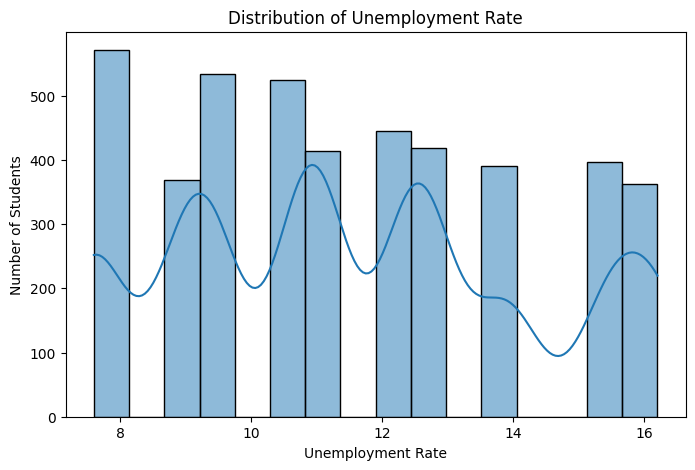

In [ ]:
# Distribution of Unemployment Rate

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Unemployment rate",
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate")
plt.ylabel("Number of Students")

plt.show()

The distribution of the unemployment rate is relatively spread across the observed range, from approximately 7.6 to 16.2, with values concentrated around 9–14.

The distribution is fairly balanced with only a slight positive skew, indicating that there is no strong distortion toward either extreme.

The variable does not contain unusually extreme values that requires removal or capping, so the recorded observations was retained for further analysis and preprocessing.

### 5.3. Categorical Feature Distribution

#### 5.3.1. Gender Distribution Plot.

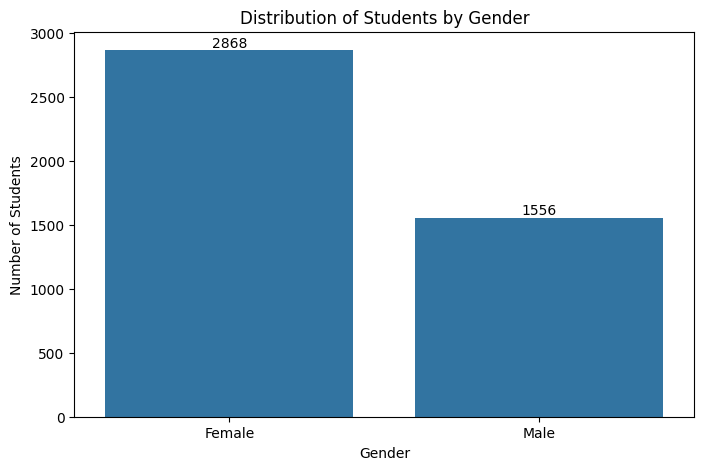

In [ ]:
# Distribution of Gender

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Gender",
    order=[0, 1]
)

plt.title("Distribution of Students by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")

# Replace numeric codes with readable labels
ax.set_xticks([0, 1])
ax.set_xticklabels(["Female", "Male"])

# Add counts on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of gender shows that female students are more highly represented than male students in the dataset, with approximately two-thirds of the students being female and one-third being male.

This indicates a noticeable gender imbalance within the sample, although both groups contain a substantial number of observations.

The difference in representation will be considered when examining relationships between gender and the target outcome, but the imbalance is not severe enough to be the reason for we removing or altering observations based on gender.

#### 5.3.1. Scholarship Holder Distribution Plot.

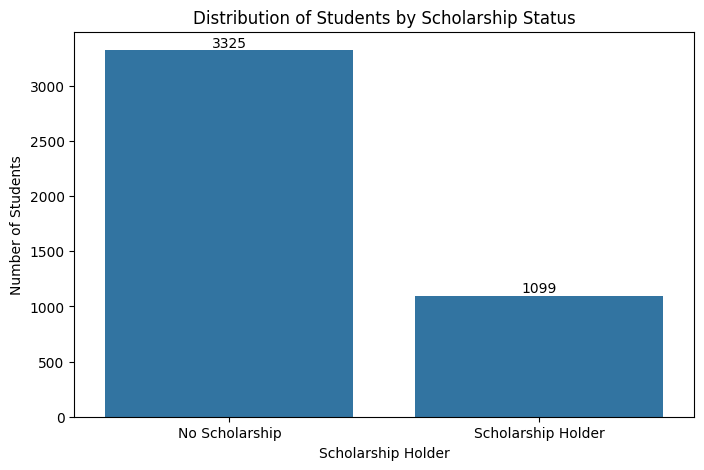

In [ ]:
# Distribution of Scholarship Holder

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Scholarship holder",
    order=[0, 1]
)

plt.title("Distribution of Students by Scholarship Status")
plt.xlabel("Scholarship Holder")
plt.ylabel("Number of Students")

# Replace numeric codes with readable labels
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Scholarship", "Scholarship Holder"])

# Add counts on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of scholarship status shows that the majority of students in the dataset are not scholarship holders, while a smaller proportion receive scholarships.

Approximately 75.2% of the students do not hold a scholarship compared with 24.8% who do.

This indicates an uneven distribution between the two groups, although both groups contain sufficient observations for comparison.

The variable was therefore retained and its relationship with the target outcome will be examined during further exploratory analysis.

#### 5.3.3. Debtor Distribution Distribution Plot.

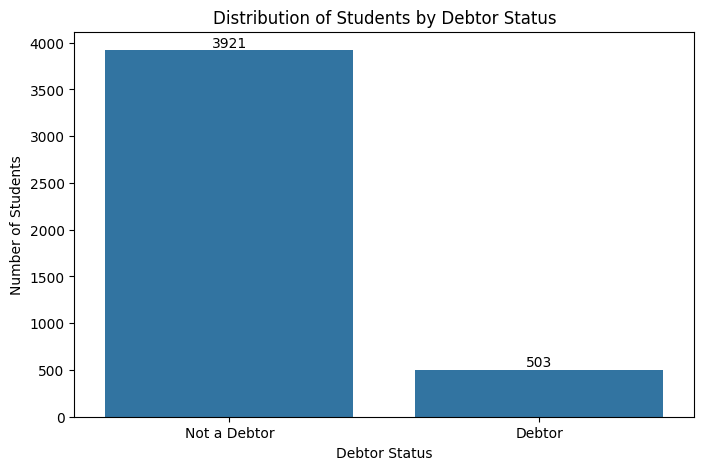

In [ ]:
# Distribution of Debtor Status

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Debtor",
    order=[0, 1]
)

plt.title("Distribution of Students by Debtor Status")
plt.xlabel("Debtor Status")
plt.ylabel("Number of Students")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Not a Debtor", "Debtor"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of debtor status shows that the vast majority of students are not debtors, while a much smaller proportion of students are classified as debtors.

Approximately 88.6% of the students are not debtors compared with 11.4% who are debtors, indicating a substantial imbalance between the two groups.

Despite this uneven distribution, both categories are represented in the dataset and will therefore be retained.

The variable may be useful for further analysis because financial status could have a relationship with students’ academic outcomes.

#### 5.3.4. Tuition Fees Up to Date Distribution Plot.

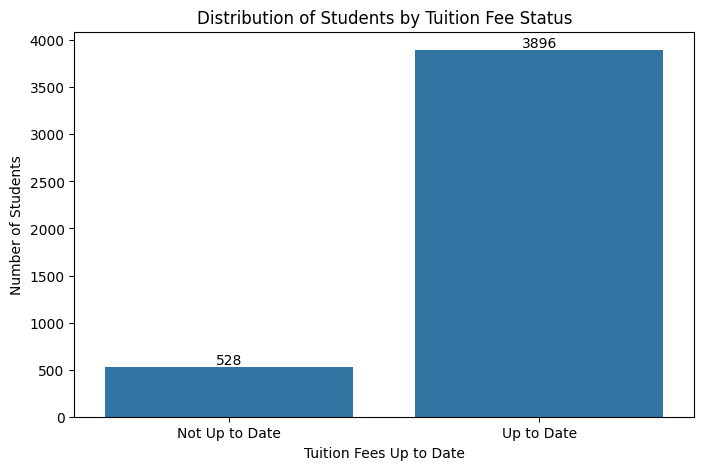

In [ ]:
# Distribution of Tuition Fees Status

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Tuition fees up to date",
    order=[0, 1]
)

plt.title("Distribution of Students by Tuition Fee Status")
plt.xlabel("Tuition Fees Up to Date")
plt.ylabel("Number of Students")

# Replace numeric codes with readable labels
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Up to Date", "Up to Date"])

# Add counts on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of tuition fee status shows that the majority of students have their tuition fees up to date, while a much smaller proportion have fees that are not up to date.

Approximately 88.1% of the students are up to date with their tuition fees compared with 11.9% who are not, indicating a substantial imbalance between the two groups.

Both categories are sufficiently represented in the dataset and will therefore be retained.

The variable may be relevant for subsequent analysis because students’ tuition payment status could be associated with their academic outcome.

#### 5.3.5. Daytime/Evening Attendance Distribution Plot

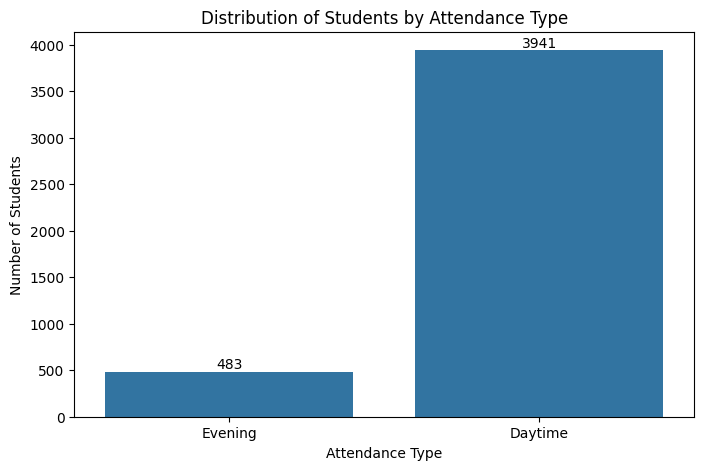

In [ ]:
# Distribution of Daytime/Evening Attendance

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Daytime/evening attendance",
    order=[0, 1]
)

plt.title("Distribution of Students by Attendance Type")
plt.xlabel("Attendance Type")
plt.ylabel("Number of Students")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Evening", "Daytime"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of attendance type shows that the majority of students attend during the daytime, while a much smaller proportion attend during the evening.

Approximation 89.1% of the students are daytime students compared with 10.9% who attend in the evening, indicating a substantial imbalance between the two groups.

Both categories are represented in the dataset, so the observations will be retained. The variable may be useful for further analysis because attendance type could be associated with students' academic outcomes.

#### 5.3.6 Distribution of Top 10 Course

The dataset contains 17 course categories. Since plotting all 17 can make the chart difficult to read, we will display only the 10 most common courses.

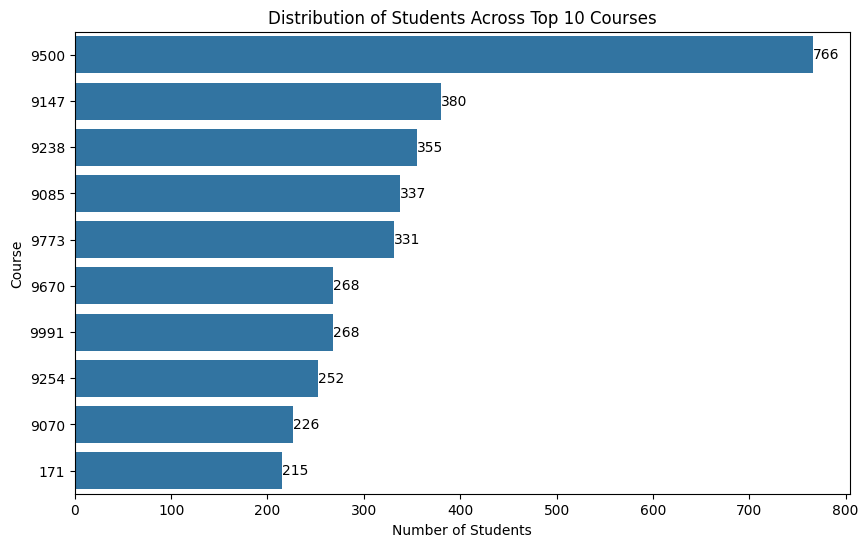

In [ ]:
# Distribution of Top 10 Courses

course_counts = df["Course"].value_counts().head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=course_counts.values,
    y=course_counts.index.astype(str)
)

plt.title("Distribution of Students Across Top 10 Courses")
plt.xlabel("Number of Students")
plt.ylabel("Course")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of students across courses is uneven, with some courses having substantially more students than others.

The most represented course has considerably more students than several of the other courses, while some courses have relatively small numbers of students.

This indicates that course representation is not balanced across the dataset.

However, the differences reflect the composition of the student population rather than errors in the data, so the observations will be retained.

Course may be an important categorical feature for analysis because students from different courses may have different academic outcome patterns.

### 5.4. Correlation Heatmap

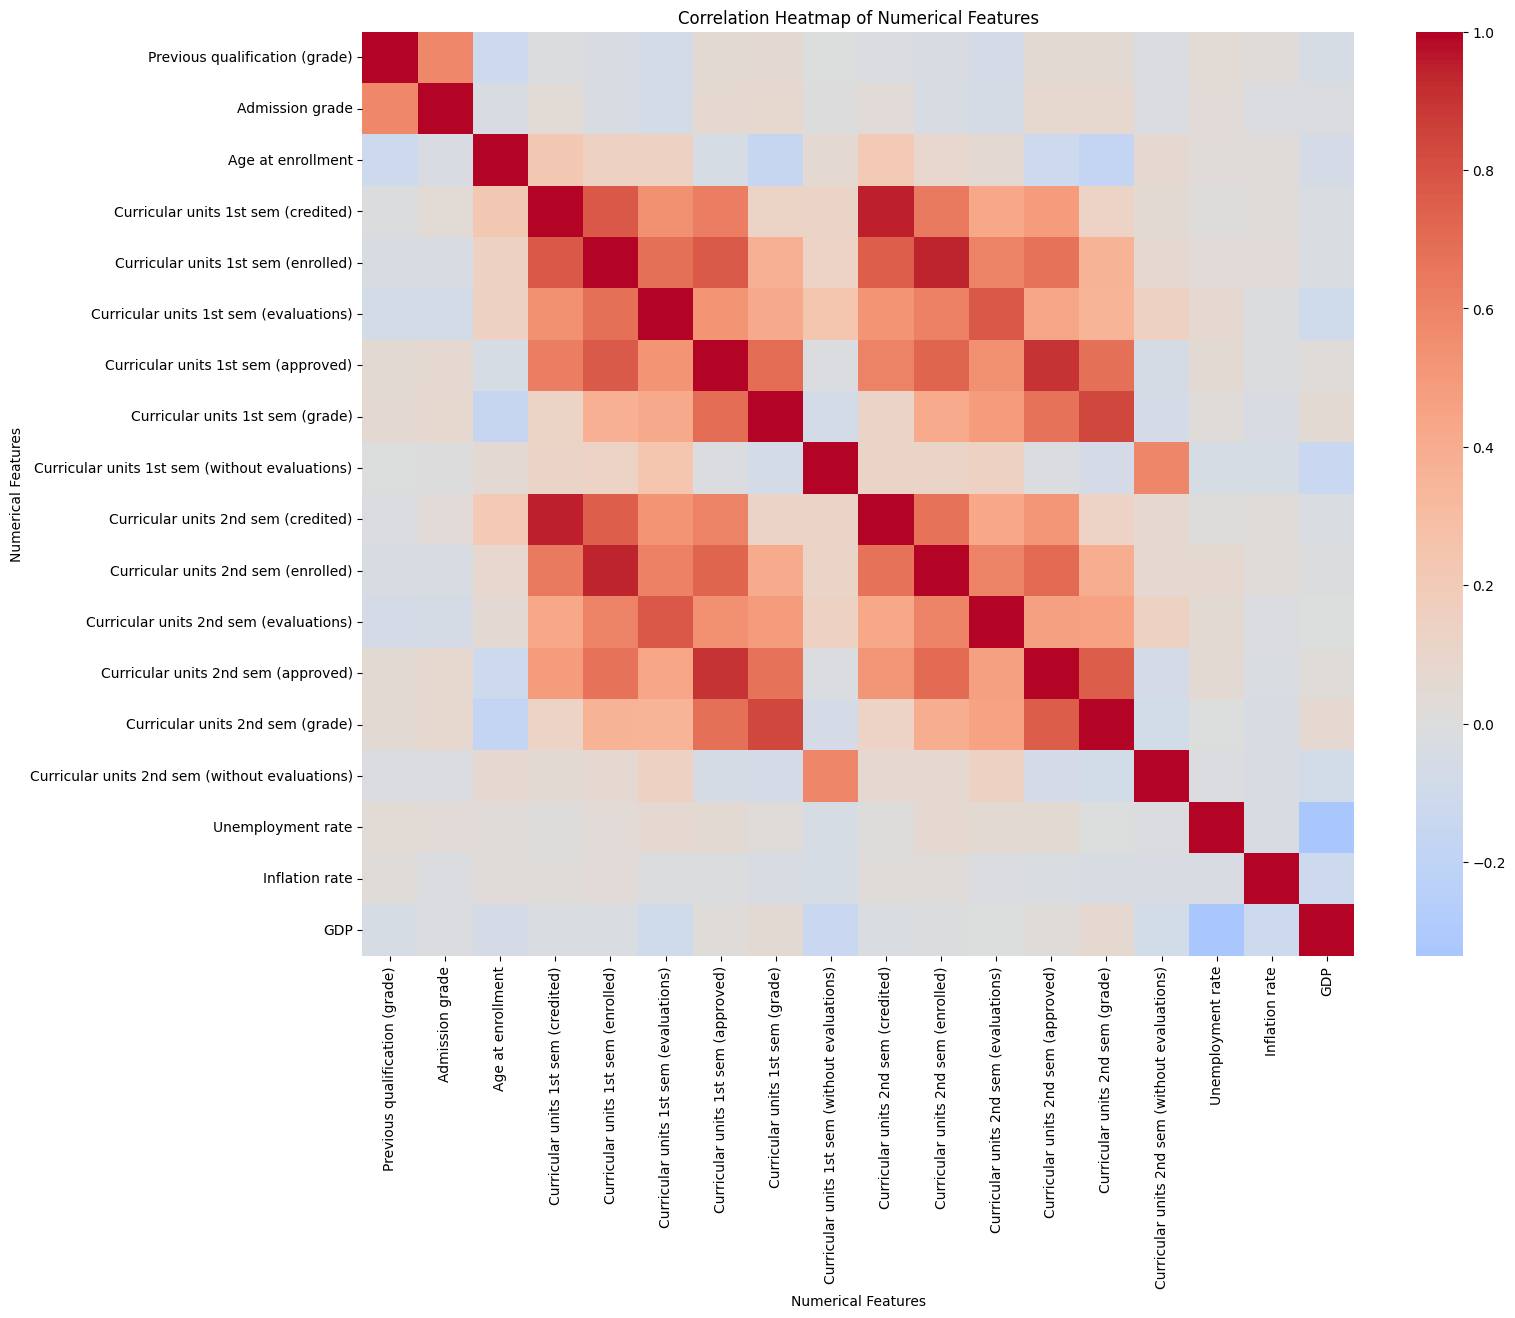

In [ ]:
# Correlation Heatmap of Numerical Features

numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.xlabel("Numerical Features")
plt.ylabel("Numerical Features")

plt.show()

The correlation heatmap shows several strong positive relationships among the students’ first- and second-semester academic variables.

The strongest relationships are observed between corresponding semester measures, particularly credited units, enrolled units, approved units, and grades, indicating that students' academic activity and performance in one semester are generally associated with their activity and performance in the other semester. Previous qualification grade, admission grade, and age show comparatively weaker relationships with most of the curricular-unit variables.

The presence of highly correlated features should be considered during preprocessing because redundant information may affect some modelling approaches, although correlated features will not be removed automatically at this stage.

### 5.5. Additional Insight Plot — Average Grade by Student Outcome

This final EDA plot is to show how academic performance differs across the three outcome classes

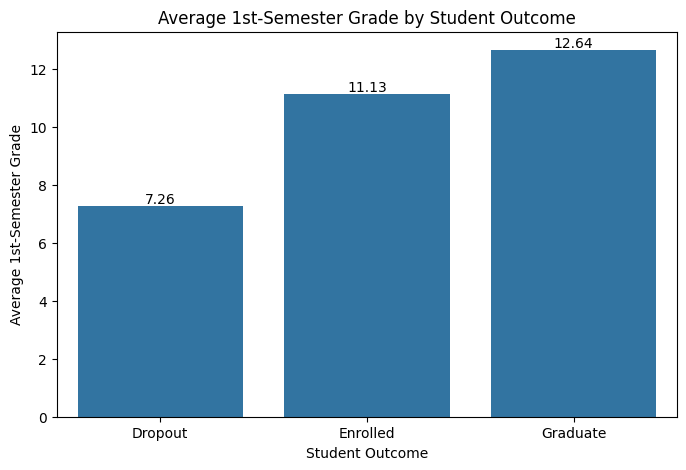

In [ ]:
# Average 1st-Semester Grade by Student Outcome

average_grade = df.groupby("Target")["Curricular units 1st sem (grade)"].mean().reindex(
    ["Dropout", "Enrolled", "Graduate"]
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=average_grade.index,
    y=average_grade.values
)

plt.title("Average 1st-Semester Grade by Student Outcome")
plt.xlabel("Student Outcome")
plt.ylabel("Average 1st-Semester Grade")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

The distribution of average 1st-semester grades differs substantially across the three student outcome groups.

Students who eventually dropped out have the lowest average 1st-semester grade, at approximately 7.26, while enrolled students have a higher average of approximately 11.13 and graduates have the highest average of approximately 12.64.

This pattern indicates a strong association between early academic performance and eventual student outcome, suggesting that curricular unit grades may be important predictive features for the classification models.

However, this relationship should be interpreted carefully because the dataset contains academic-performance information from the first semester, and its use is dependent on the defined prediction point.

## 6. Preprocessing of Our Data

### 6.1. Selecting the target and Features

In [ ]:
# Separate the target variable from the predictor variables
X = df.drop("Target", axis=1)

# Store the target variable separately
y = df["Target"]

# Display the dimensions of the predictors
print("Features shape:", X.shape)

# Display the dimensions of the target
print("Target shape:", y.shape)

Features shape: (4424, 36)
Target shape: (4424,)


### 6.2. Checking the Data Classes

We have to confirm our Data classes before splitting our data.

In [ ]:
# Count the number of students in each target class
print(y.value_counts())

# Calculate the percentage of each target class
print(y.value_counts(normalize=True).mul(100).round(2))

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


### 6.3. Train-Test Split

We will be splitting our data by an 80/20 split to prevent the overfitting of our model to the data set.

And because our target classes are imbalanced, we'll use stratification.

Without stratification, the random split could accidentally produce different proportions of Dropout, Enrolled, and Graduate students in the training and testing sets.

In [ ]:
# Import the train-test split function
from sklearn.model_selection import train_test_split

# Split the data while preserving the target class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the training set size
print("Training set:", X_train.shape)

# Display the testing set size
print("Testing set:", X_test.shape)

Training set: (3539, 36)
Testing set: (885, 36)


### 6.4. Checking the split

This is to verify that the class distribution is preserved.

In [ ]:
# Display class percentages in the training set
print("Training set distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

# Display class percentages in the testing set
print("\nTesting set distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set distribution:
Target
Graduate    49.93
Dropout     32.13
Enrolled    17.94
Name: proportion, dtype: float64

Testing set distribution:
Target
Graduate    49.94
Dropout     32.09
Enrolled    17.97
Name: proportion, dtype: float64


### 6.5. Identify the feature types

We will have to identify what type of infromation each data represents in order to know which one to encode or scale.

In [ ]:
# Display the data type of every feature
print(X.dtypes)

Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nationality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

### 6.6.Defining Our Numerical Features

This is select  only the numerical features for preprocessing.

In [ ]:
# Define the continuous and count-based numerical features
numerical_features = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

# Display the number of numerical features
print("Number of numerical features:", len(numerical_features))

Number of numerical features: 18


### 6.7. Defining the Categorical Features

The remaining predictors are coded categories. We will be defining them now for our model.

In [ ]:
# Identify features that are not numerical
categorical_features = [
    column for column in X.columns
    if column not in numerical_features
]

# Display the categorical feature names
print("Categorical features:")
print(categorical_features)

# Display the number of categorical features
print("\nNumber of categorical features:", len(categorical_features))

Categorical features:
['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nationality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

Number of categorical features: 18


We have 18 numerical + 18 categorical = 36 predictors.

### 6.8. Why are we separating them?

This is a important for us to understand.
Imagine we have:
Age = 20,
Age = 21,
Age = 22.

These numbers have a natural numerical relationship.
But consider:
Gender -
0 = Female;
1 = Male

The fact that Male is represented by 1 and Female by 0 does not mean that Male is "one unit greater" than Female.
Similarly:
Course = 9500,
Course = 9147,
Course = 9238.

These are codes, not quantities.
Therefore, we shouldn't blindly scale every int64 column.

### 6.9. Checking our feature group

In [ ]:
# Confirm the total number of assigned features
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numerical_features) + len(categorical_features))
print("Original features:", X.shape[1])

Numerical features: 18
Categorical features: 18
Total features: 36
Original features: 36


This was to make sure that every feature has been assigned to one group and nothing has accidentally been omitted.

### 6.10. Creating our Preprocessing pipeline

We'll be building a ColumnTransformer that performs two different operations:

1. Standard Scaling for numerical features.
2. One hot encoding for categorical features.

We wiil be using Scikit-learn's ColumnTransformer because it's the cleanest way to do it.

In [ ]:
# Import tools for preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Create the numerical preprocessing step
numerical_transformer = StandardScaler()

# Create the categorical preprocessing step
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine the two preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Display the preprocessing structure
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Previous qualification (grade)',
                                  'Admission grade', 'Age at enrollment',
                                  'Curricular units 1st sem (credited)',
                                  'Curricular units 1st sem (enrolled)',
                                  'Curricular units 1st sem (evaluations)',
                                  'Curricular units 1st sem (approved)',
                                  'Curricular units 1st sem (grade)',
                                  'Curricular units 1st sem (without '
                                  'evaluations)',
                                  'Curricular...
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Marital Status', 'Application mode',
                                  'Application order', 'Course',
                                  'Daytime/eveni

Why we had to perform the preprocessing operation above?

Numerical features → StandardScaler: This puts numerical variables on a comparable scale.


Categorical features → OneHotEncoder: This converts categories into machine-readable binary columns without incorrectly implying numerical relationships between category codes.

We also added the code line (handle_unknown="ignore") to prevent our model from treating new categories that will be appear in our test data separate from our training data as error.

Instead of producing an error, the encoder can handle the previously unseen category.

### 6.11. Fitting the Preprocessor ONLY on Training Data

This is for our model to learn the preprocessing parameters from X_train only.

In [ ]:
# Fit the preprocessing transformations using training data only
preprocessor.fit(X_train)

# Transform the training data
X_train_processed = preprocessor.transform(X_train)

# Transform the testing data using the same fitted transformations
X_test_processed = preprocessor.transform(X_test)

# Display the processed training shape
print("Processed training shape:", X_train_processed.shape)

# Display the processed testing shape
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (3539, 251)
Processed testing shape: (885, 251)


Why we had to fit only to X_train?

We want the model to behave as though it has never seen the test data before.
For example, the scaler calculates the training mean and standard deviation from:
X_train

It then uses those same values to transform:
X_test

We do not calculate a separate mean and standard deviation from the test set.
That prevents information from the test set leaking into the training process.

### 6.12. Checking the Processed Data

This is to confirm if what we did worked.

In [ ]:
# Display the type of the processed training data
print("Processed data type:", type(X_train_processed))

# Display the processed data dimensions
print("Processed training dimensions:", X_train_processed.shape)

Processed data type: <class 'scipy.sparse._csr.csr_matrix'>
Processed training dimensions: (3539, 251)


The number of columns after preprocessing will be greater than 36 because one categorical feature can become many columns after one-hot encoding.

## 7. TRAINING AND EVALUATION OF MODEL 1

### 7.1. TRAINING MODEL 1

We will be using Logistic Regression (a standard classification algorithm) as our baseline model.

It works naturally with our multiclass target: Dropout, Enrolled, and Graduate.



#### 7.1.1. Importing the Logistic Regression model

In [ ]:
# Import the logistic regression classifier
from sklearn.linear_model import LogisticRegression

# Create the logistic regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Display the model configuration
print(logistic_model)

LogisticRegression(max_iter=1000, random_state=42)


#### 7.1.2. Training the Model using Linear Regression

In [ ]:
# Train the logistic regression model
logistic_model.fit(X_train_processed, y_train)

# Confirm that training has completed
print("Logistic Regression training completed.")

Logistic Regression training completed.


#### 7.1.3. Generating Test Predictions for Model 1

In [ ]:
# Generate predictions for the unseen test data
y_pred_logistic = logistic_model.predict(X_test_processed)

# Display the first few predictions
print(y_pred_logistic[:10])

['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Dropout'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']


### 7.2. EVALUATING MODEL 1

In [ ]:
# Import classification evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate overall accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

# Calculate weighted precision
logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

# Calculate weighted recall
logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

# Calculate weighted F1-score
logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

# Display the evaluation results
print("Logistic Regression Results")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1-score:", round(logistic_f1, 4))

Logistic Regression Results
Accuracy: 0.7684
Precision: 0.7552
Recall: 0.7684
F1-score: 0.7577


### 7.3. CLASSIFICATION REPORT FOR MODEL 1

In [ ]:
# Import the classification report
from sklearn.metrics import classification_report

# Display precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.55      0.40      0.46       159
    Graduate       0.81      0.91      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.69      0.70       885
weighted avg       0.76      0.77      0.76       885



### 7.4 LOGISTIC REGRESSION CONFUSION MATRICS

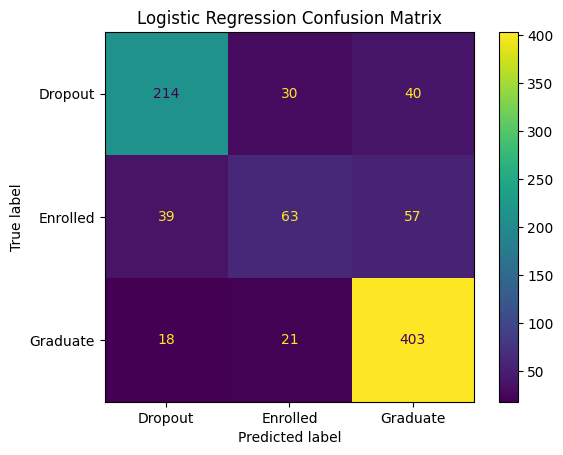

In [ ]:
# Import the confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["Dropout", "Enrolled", "Graduate"]
)

# Create the confusion matrix display
logistic_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Dropout", "Enrolled", "Graduate"]
)

# Plot the confusion matrix
logistic_display.plot()

# Add a descriptive title
plt.title("Logistic Regression Confusion Matrix")

# Display the plot
plt.show()

## 8. TRAINING AND EVALUATION OF MODEL 2

### 8.1. TRAINING MODEL 2

We will be using Random Forest as our second model.

It help our model to perform better by modelling non-linear relationships between features unlike Logistical Regression that models simple linear relationships.

#### 8.1.1. Importing the Random forest Model

In [ ]:
# Import the random forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create the random forest model
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Display the model configuration
print(random_forest_model)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)


#### 8.1.2. Training the Model using Random Forest

In [ ]:
# Train the random forest using the processed training data
random_forest_model.fit(X_train_processed, y_train)

# Confirm that training has completed
print("Random Forest training completed.")

Random Forest training completed.


#### 8.1.3. Generating Test Predictions for Model 2

In [ ]:
# Generate predictions for the unseen test data
y_pred_rf = random_forest_model.predict(X_test_processed)

# Display the first few predictions
print(y_pred_rf[:10])

['Graduate' 'Graduate' 'Dropout' 'Graduate' 'Graduate' 'Graduate'
 'Graduate' 'Graduate' 'Graduate' 'Graduate']


### 8.2. EVALUATING MODEL 2

In [ ]:
# Calculate the overall accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Calculate weighted precision
rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

# Calculate weighted recall
rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

# Calculate weighted F1-score
rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

# Display the random forest results
print("Random Forest Results")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1-score:", round(rf_f1, 4))

Random Forest Results
Accuracy: 0.7571
Precision: 0.7347
Recall: 0.7571
F1-score: 0.7353


### 8.3. CLASSIFICATION REPORT FOR MODEL 2

In [ ]:
# Display precision, recall, F1-score, and support for each class
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.52      0.27      0.36       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.69      0.65      0.66       885
weighted avg       0.73      0.76      0.74       885



### 8.4 RANDOM FOREST CONFUSION MATRICS

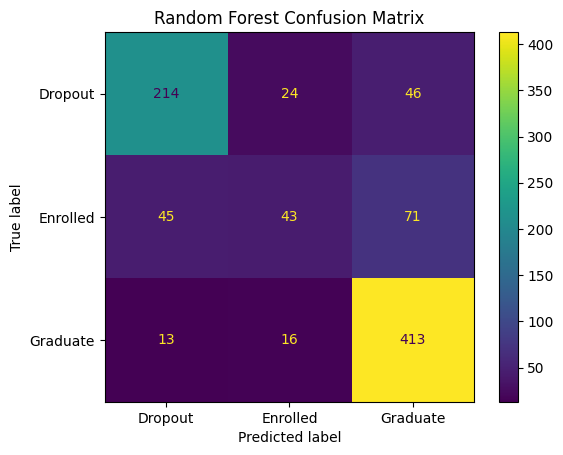

In [ ]:
# Calculate the random forest confusion matrix
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Dropout", "Enrolled", "Graduate"]
)

# Create the confusion matrix display
rf_display = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Dropout", "Enrolled", "Graduate"]
)

# Plot the confusion matrix
rf_display.plot()

# Add a descriptive title
plt.title("Random Forest Confusion Matrix")

# Display the plot
plt.show()